# Solar Energy Production Prediction

**Machine Learning Internship Project**

### Objective
Build a regression model to estimate **annual PV energy production (kWh)** for solar projects using project, location, system-size, storage, metering and date-related information.

This version keeps the original internship approach, but makes the notebook cleaner, more reproducible, easier to explain, and ready for Streamlit deployment.

> **Important:** The final model keeps PV system size because it is a valid input when estimating the expected production of a proposed/known solar installation. A second experiment removes system-size variables to show how much predictive information they provide.


## 1. Imports

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save the trained model for Streamlit
import joblib
import json
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

The original notebook used Google Drive in Google Colab, so that workflow is kept.

**Change only `DATA_PATH` if your folder is different.**


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DATA_PATH = (
    "/content/drive/MyDrive/Portfolio Website/Projects/Solar Energy/Solar Energy.csv"
)

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (218115, 17)


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


## 3. Dataset Overview

The dataset contains project-level information about solar installations.

The main target is **Estimated Annual PV Energy Production (kWh)**.

Important fields include:

- project and location information
- utility, developer and metering method
- PV system size in kWdc and kWac
- energy storage size
- interconnection date
- estimated annual PV energy production


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.describe(include="all").T)


Rows: 218115
Columns: 17


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Data Through Date,218115,1,12/31/2023,218115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project ID,218112,218077,LDG-00050,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Interconnection Date,218115,5411,2/11/2016,313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utility,218115,7,PSEGLI,85110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City/Town,218057,3009,STATEN ISLAND,6884,NaN,NaN,NaN,NaN,NaN,NaN,NaN
County,218115,62,Suffolk,51715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip,218019.0,NaN,NaN,NaN,11751.734473,962.129108,10001.0,11220.0,11717.0,12018.0,14905.0
Division,132881,109,CENY-Q,21813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Substation,138171,2255,Jamaica,11581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Circuit ID,218085,6429,JA NWK,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Initial Data Checks

In [5]:
# Check data types
df.info()

# Missing values
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

# Number of unique values
print("\nUnique values:")
display(df.nunique().sort_values(ascending=False))

# Remove exact duplicate rows, matching the original project approach.
before = len(df)
df = df.drop_duplicates().copy()
print(f"Removed {before - len(df)} duplicate rows.")
print("New shape:", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

,0
Energy Storage System Size (kWac),214024
Division,85234
Substation,79944
Developer,10550
Metering Method,463
Zip,96
City/Town,58
Circuit ID,30
Project ID,3
Data Through Date,0



Unique values:


,0
Project ID,218077
Circuit ID,6429
Interconnection Date,5411
Estimated Annual PV Energy Production (kWh),3769
Estimated PV System Size (kWdc),3191
PV System Size (kWac),3095
City/Town,3009
Developer,2567
Substation,2255
Zip,1729


Removed 0 duplicate rows.
New shape: (218115, 17)


## 5. Exploratory Data Analysis

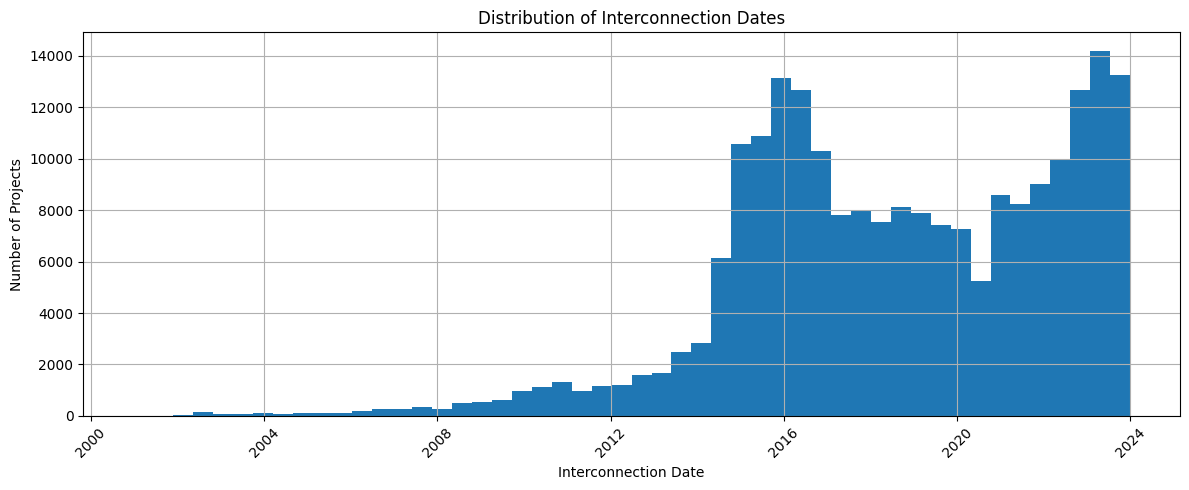

In [6]:
# Convert the interconnection date for visualisation.
df["Interconnection Date"] = pd.to_datetime(
    df["Interconnection Date"], errors="coerce"
)

# Distribution of interconnection dates
plt.figure(figsize=(12, 5))
df["Interconnection Date"].hist(bins=50)
plt.title("Distribution of Interconnection Dates")
plt.xlabel("Interconnection Date")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


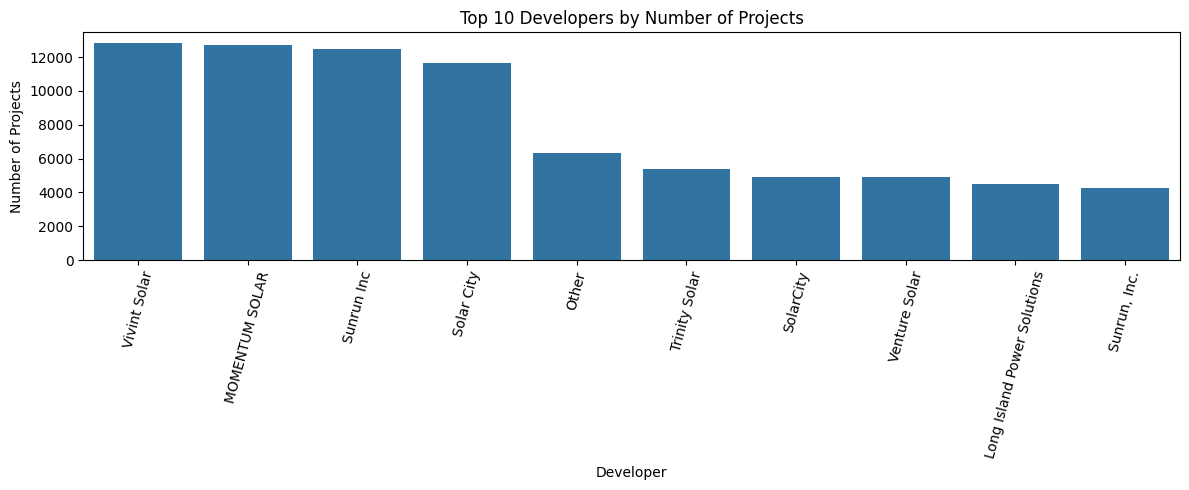

In [7]:
# Top 10 developers by project count
top_developers = df["Developer"].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_developers.index, y=top_developers.values)
plt.title("Top 10 Developers by Number of Projects")
plt.xlabel("Developer")
plt.ylabel("Number of Projects")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


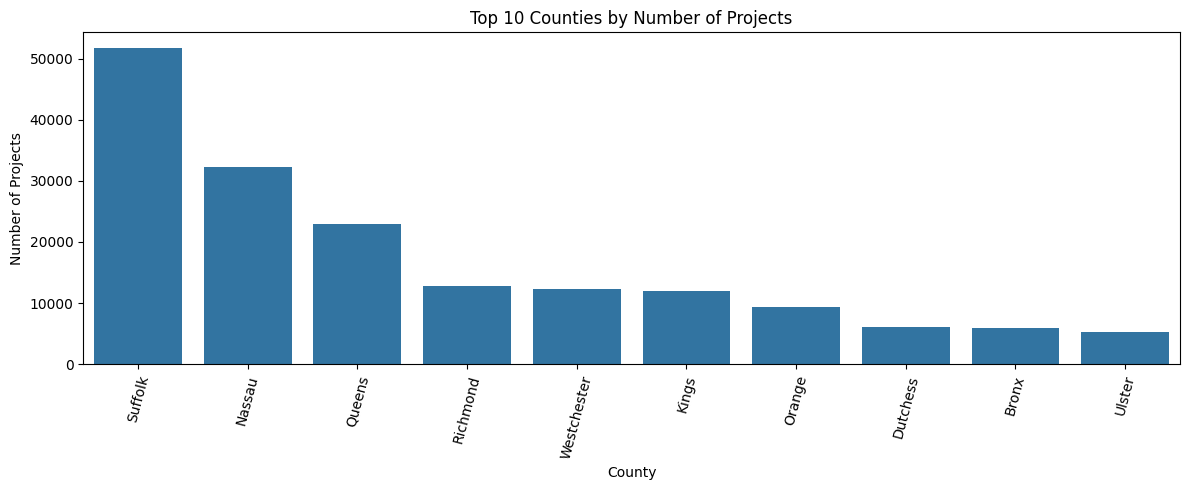

In [8]:
# Top 10 counties by project count
top_counties = df["County"].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_counties.index, y=top_counties.values)
plt.title("Top 10 Counties by Number of Projects")
plt.xlabel("County")
plt.ylabel("Number of Projects")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


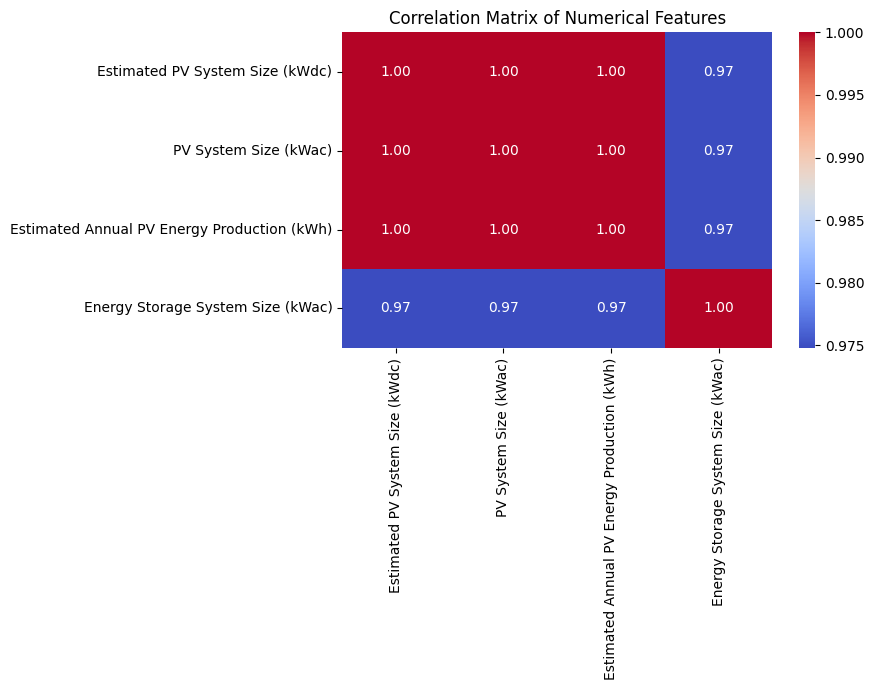

In [9]:
# Correlation between the main numerical variables
numerical_features = [
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)",
    "Estimated Annual PV Energy Production (kWh)",
    "Energy Storage System Size (kWac)",
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


## 6. Data Cleaning and Feature Engineering

In [10]:
def engineer_features(data):
    """Clean the raw data and create the features used by the model."""

    df = data.copy()

    # Convert date columns safely.
    df["Data Through Date"] = pd.to_datetime(
        df["Data Through Date"], errors="coerce"
    )
    df["Interconnection Date"] = pd.to_datetime(
        df["Interconnection Date"], errors="coerce"
    )

    # Projects without recorded storage are treated as having 0 kWac storage.
    df["Energy Storage System Size (kWac)"] = (
        df["Energy Storage System Size (kWac)"].fillna(0)
    )

    # 1. Project age
    df["Project Age"] = (
        df["Data Through Date"] - df["Interconnection Date"]
    ).dt.days

    # 2. Interconnection date components
    df["Interconnection Year"] = df["Interconnection Date"].dt.year
    df["Interconnection Month"] = df["Interconnection Date"].dt.month
    df["Interconnection Day"] = df["Interconnection Date"].dt.day

    # 3. Cyclical month/day features
    df["Interconnection Month_sin"] = np.sin(
        2 * np.pi * df["Interconnection Month"] / 12
    )
    df["Interconnection Month_cos"] = np.cos(
        2 * np.pi * df["Interconnection Month"] / 12
    )
    df["Interconnection Day_sin"] = np.sin(
        2 * np.pi * df["Interconnection Day"] / 31
    )
    df["Interconnection Day_cos"] = np.cos(
        2 * np.pi * df["Interconnection Day"] / 31
    )

    # 4. System efficiency
    df["System Efficiency"] = np.where(
        df["Estimated PV System Size (kWdc)"] != 0,
        df["PV System Size (kWac)"]
        / df["Estimated PV System Size (kWdc)"],
        0,
    )

    # 5. Storage capacity relative to AC system size
    df["Storage Capacity Ratio"] = np.where(
        df["PV System Size (kWac)"] != 0,
        df["Energy Storage System Size (kWac)"]
        / df["PV System Size (kWac)"],
        0,
    )

    # 6. Utility + county interaction
    df["Utility_County"] = (
        df["Utility"].fillna("Unknown").astype(str)
        + "_"
        + df["County"].fillna("Unknown").astype(str)
    )

    # Remove identifiers, constants and raw date columns.
    # Project ID is deliberately removed because it is an identifier,
    # not a meaningful predictor.
    df.drop(
        columns=[
            "Data Through Date",
            "Number of Projects",
            "Project ID",
            "Interconnection Date",
            "Interconnection Month",
            "Interconnection Day",
        ],
        inplace=True,
        errors="ignore",
    )

    return df


model_df = engineer_features(df)

print("Model-ready shape:", model_df.shape)
display(model_df.head())


Model-ready shape: (218115, 22)


,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),...,Energy Storage System Size (kWac),Project Age,Interconnection Year,Interconnection Month_sin,Interconnection Month_cos,Interconnection Day_sin,Interconnection Day_cos,System Efficiency,Storage Capacity Ratio,Utility_County
0,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,...,0.0,2,2023,-2.449294e-16,1.0,-0.394356,0.918958,0.854545,0.0,Con Ed_Queens
1,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,...,0.0,2,2023,-2.449294e-16,1.0,-0.394356,0.918958,0.854599,0.0,Con Ed_Bronx
2,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,...,0.0,2,2023,-2.449294e-16,1.0,-0.394356,0.918958,0.855738,0.0,Con Ed_Kings
3,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,...,0.0,2,2023,-2.449294e-16,1.0,-0.394356,0.918958,0.854093,0.0,Con Ed_Kings
4,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,...,0.0,3,2023,-2.449294e-16,1.0,-0.571268,0.820763,0.854545,0.0,Con Ed_Queens


## 7. Prepare Features and Target

We use **Estimated Annual PV Energy Production (kWh)** as the target.

The categorical variables are handled with an `OrdinalEncoder` that can safely assign `-1` to categories not seen during training. This is useful later when the model is used in Streamlit.


In [11]:
TARGET = "Estimated Annual PV Energy Production (kWh)"

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Number of features:", X.shape[1])
print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numeric_cols))


Number of features: 21
Categorical features: 9
Numerical features: 12


## 8. Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 174492
Testing rows: 43623


## 9. Preprocessing Pipeline

Instead of manually label-encoding columns before the split, preprocessing is placed inside a Scikit-Learn pipeline.

This makes the workflow cleaner and prevents the preprocessing objects used during training from being lost when the model is deployed.


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_cols,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),
                    (
                        "encoder",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]
            ),
            categorical_cols,
        ),
    ],
    remainder="drop",
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 10. Random Forest Regression

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model),
    ]
)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("---------------------")
print(f"MAE : {mae:,.2f} kWh")
print(f"RMSE: {rmse:,.2f} kWh")
print(f"R²  : {r2:.4f}")


Random Forest Results
---------------------
MAE : 193.52 kWh
RMSE: 20,390.29 kWh
R²  : 0.9963


## 11. Actual vs Predicted Values

,Actual,Predicted
0,5494,5494.0
1,11097,11097.0
2,9339,9339.0
3,8378,8378.0
4,7293,7293.0
5,11729,11729.0
6,8364,8364.0
7,7966,7966.0
8,5603,5603.0
9,16728,16728.0


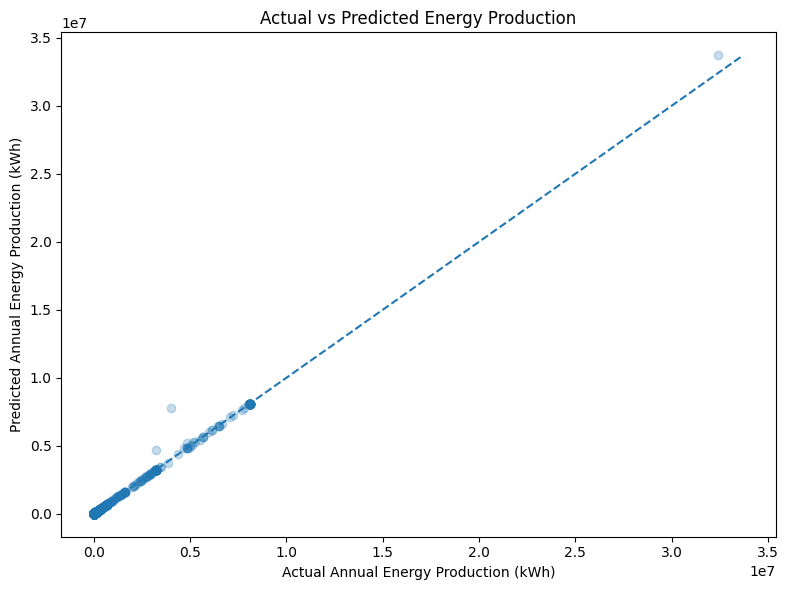

In [15]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})

display(results.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.25)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
)

plt.xlabel("Actual Annual Energy Production (kWh)")
plt.ylabel("Predicted Annual Energy Production (kWh)")
plt.title("Actual vs Predicted Energy Production")
plt.tight_layout()
plt.show()


## 12. Feature Importance

,Feature,Importance
2,numeric__PV System Size (kWac),0.491238
1,numeric__Estimated PV System Size (kWdc),0.483238
4,numeric__Project Age,0.011501
5,numeric__Interconnection Year,0.010054
10,numeric__System Efficiency,0.003394
7,numeric__Interconnection Month_cos,0.000292
0,numeric__Zip,0.000260
8,numeric__Interconnection Day_sin,0.000004
16,categorical__Substation,0.000003
17,categorical__Circuit ID,0.000003


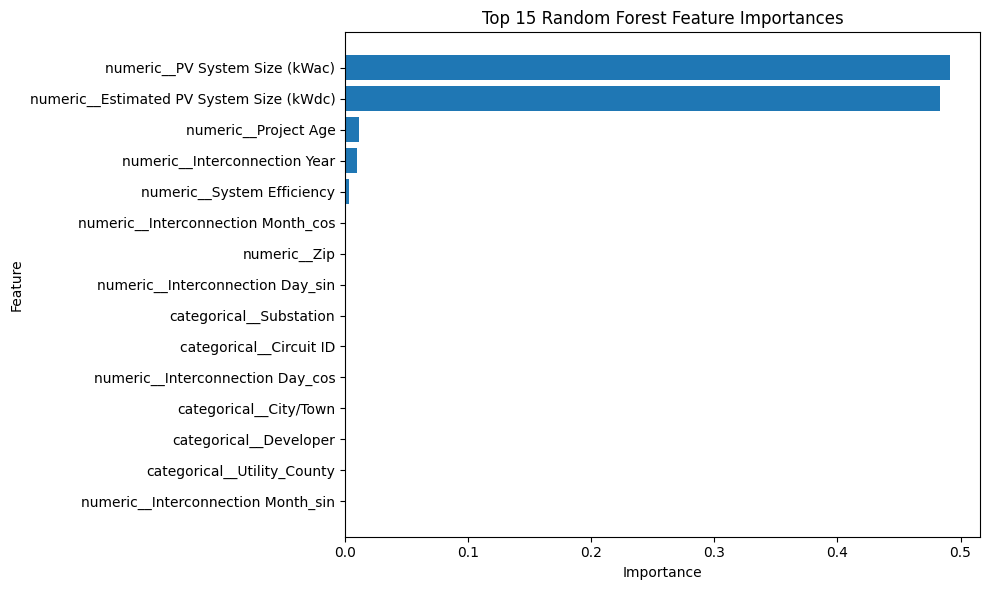

In [16]:
feature_names = (
    model_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = model_pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    })
    .sort_values("Importance", ascending=False)
)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
top_features = importance_df.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## 13. Comparison Experiment: Remove PV System Size

The original project correctly noticed that system-size variables have a very strong relationship with annual energy production.

Here we repeat the Random Forest experiment after removing:

- Estimated PV System Size (kWdc)
- PV System Size (kWac)

This is **not** the deployed model. It is an analytical comparison showing how much predictive information comes from system capacity.


In [17]:
comparison_drop = [
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)",
]

X_without_size = X.drop(columns=comparison_drop)

cat2 = X_without_size.select_dtypes(include=["object"]).columns.tolist()
num2 = [col for col in X_without_size.columns if col not in cat2]

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), num2),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]
            ),
            cat2,
        ),
    ]
)

comparison_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_2),
        (
            "model",
            RandomForestRegressor(
                n_estimators=80,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_without_size,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

comparison_model.fit(X_train_2, y_train_2)
y_pred_2 = comparison_model.predict(X_test_2)

r2_2 = r2_score(y_test_2, y_pred_2)
mae_2 = mean_absolute_error(y_test_2, y_pred_2)
rmse_2 = mean_squared_error(y_test_2, y_pred_2) ** 0.5

print("Random Forest Without System Size")
print("----------------------------------")
print(f"MAE : {mae_2:,.2f} kWh")
print(f"RMSE: {rmse_2:,.2f} kWh")
print(f"R²  : {r2_2:.4f}")


Random Forest Without System Size
----------------------------------
MAE : 9,755.49 kWh
RMSE: 218,602.16 kWh
R²  : 0.5749


## 14. Model Comparison

The comparison helps explain an important limitation of this dataset.

The final model uses system size because it is normally known when estimating production for a solar installation. However, the experiment without system size shows that the remaining project/location information alone is much less predictive.

The model should therefore **not** be presented as if it independently discovers solar irradiance or panel performance. The dataset description itself notes that the annual production estimate considers factors such as solar irradiance, panel orientation and efficiency, but those variables are not directly present in the supplied dataset.


In [18]:
comparison_results = pd.DataFrame({
    "Model": [
        "Random Forest - Final",
        "Random Forest - Without PV System Size",
    ],
    "R²": [r2, r2_2],
    "MAE (kWh)": [mae, mae_2],
    "RMSE (kWh)": [rmse, rmse_2],
})

display(comparison_results)


,Model,R²,MAE (kWh),RMSE (kWh)
0,Random Forest - Final,0.996301,193.516455,20390.286992
1,Random Forest - Without PV System Size,0.574890,9755.486334,218602.161900


## 15. Save the Model for Streamlit

In [19]:
# Save the entire pipeline so Streamlit uses the same preprocessing
# and model that were fitted in this notebook.

MODEL_PATH = (
    "/content/drive/MyDrive/Data Science/Internship/"
    "Predicting Solar Energy Production/solar_energy_model.pkl"
)

joblib.dump(model_pipeline, MODEL_PATH)

metadata = {
    "target": TARGET,
    "random_state": RANDOM_STATE,
    "model": "RandomForestRegressor",
    "n_estimators": 100,
    "r2": float(r2),
    "mae": float(mae),
    "rmse": float(rmse),
    "comparison_r2_without_system_size": float(r2_2),
}

METADATA_PATH = (
    "/content/drive/MyDrive/Data Science/Internship/"
    "Predicting Solar Energy Production/model_metadata.json"
)

with open(METADATA_PATH, "w") as file:
    json.dump(metadata, file, indent=4)

print("Model saved to:", MODEL_PATH)
print("Metadata saved to:", METADATA_PATH)


Model saved to: /content/drive/MyDrive/Data Science/Internship/Predicting Solar Energy Production/solar_energy_model.pkl
Metadata saved to: /content/drive/MyDrive/Data Science/Internship/Predicting Solar Energy Production/model_metadata.json


## 16. Example Prediction

This cell demonstrates the same type of prediction that the Streamlit application will make.


In [20]:
sample_project = X_test.iloc[[0]].copy()

sample_prediction = model_pipeline.predict(sample_project)[0]

print(
    f"Predicted annual PV energy production: "
    f"{sample_prediction:,.0f} kWh"
)


Predicted annual PV energy production: 5,494 kWh


## 17. Conclusion

### What was achieved

- Cleaned and explored the solar project dataset.
- Removed duplicate records and irrelevant identifiers.
- Handled missing values through a reproducible preprocessing pipeline.
- Created date, efficiency, storage and utility-location features.
- Trained a Random Forest regression model.
- Evaluated the model using MAE, RMSE and R².
- Compared performance after removing direct PV system-size variables.
- Saved the complete model pipeline for Streamlit deployment.

### Limitation

The dataset does not directly contain detailed weather/irradiance, panel orientation, tilt or other physical variables that would allow a more independent prediction of solar production.

Therefore, the model is best described as an **estimate based on available project information**, rather than a complete physical solar-production model.
